# Fake News Detection with Graph Neural Networks
Date: 2026

**Kurzbeschreibung**:
Dieses Notebook beinhaltet ein grundlegendes GNN, welches mittels zweier graphischer konvolutioneller Schichten auf 70 % der Gossipcop-Netzwerke trainiert wurde. Der Verlust wurde gedruckt, um zu überprüfen, ob das Netzwerk trainiert wurde.

Ebenfalls wird auf Validation und Testset einige Metriken getested um zu überprüfen das nicht zu stark overfitted wird.

**Quellen**:
* https://distill.pub/2021/gnn-intro/

## Datenset Initialisierung

Datenset wird mittels FNNDataset dataloader geladen da dieser vom Datenset spezifisch für Training zur Verfügung gestellt wird, sample output wird gegeben um zu verstehen was für ein Netzwerk das GNN trainiert.

Loaded dataset: gossipcop(5464)
Number of graphs: 5464
Feature dim: 300
Data(edge_index=[2, 113], x=[57, 300], y=[1])

Data fields: ['y', 'edge_index', 'x']
Number of nodes: 57
Number of edges: 113
Label (fake=0, real=1): 0
Node feature vector (first 3 rows):
tensor([[-5.2563e-03,  1.0564e-01, -1.7796e-02, -2.0361e-02,  7.5127e-02,
         -1.5702e-02,  3.2114e-02, -9.1181e-02,  4.1364e-02,  1.7600e+00,
         -1.6639e-01,  5.7241e-02,  4.8859e-03, -5.2453e-02, -5.3290e-02,
         -4.3913e-02, -7.3703e-03,  7.5893e-01, -1.3094e-01, -3.8563e-02,
          2.4300e-02, -5.8674e-02, -3.3233e-02, -1.0867e-02,  6.0425e-02,
          2.8623e-02, -4.7315e-02, -3.7680e-02, -6.6707e-03,  2.1653e-02,
         -2.8474e-02,  6.5221e-02, -3.2195e-02,  4.2343e-02,  8.8444e-02,
         -7.7411e-02, -3.7643e-02, -1.1120e-02, -4.1929e-02, -5.6125e-02,
          7.7358e-02,  1.0041e-01,  1.7153e-02, -3.5056e-02,  5.4995e-02,
          2.3231e-02, -6.8462e-02,  4.2650e-03,  4.4027e-02, -2.9072e-02,


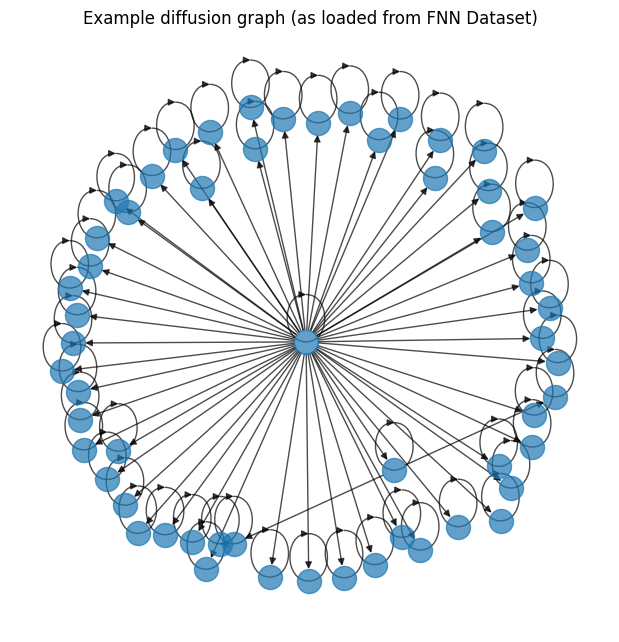

Train size: 3826
Val size: 1092
Test size: 546


In [2]:
import os
import sys
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from SimpleGNN import SimpleGNN
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
from pprint import pprint

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.utils.data_loader import FNNDataset


# --- Load dataset ---
root = os.path.join(root_dir, "data")
dataset = FNNDataset(root=root, name="gossipcop", feature="spacy")

print(f"Loaded dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Feature dim: {dataset.num_node_attributes}")

# --- Inspect one graph ---
data = dataset[0]
print(data)
print()
print("Data fields:", data.keys())
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Label (fake=0, real=1):", data.y.item())

# --- Check the first few node features ---
print("Node feature vector (first 3 rows):")
print(data.x[:3])


G = to_networkx(data)
plt.figure(figsize=(6, 6))
nx.draw(G, alpha=0.7)
plt.title("Example diffusion graph (as loaded from FNN Dataset)")
plt.show()

# --- Check splits ---
print("Train size:", len(dataset.test_idx))
print("Val size:", len(dataset.train_idx))
print("Test size:", len(dataset.val_idx))


In [8]:
# Assuming dataset.train_idx, dataset.val_idx, dataset.test_idx exist
train_dataset = Subset(dataset, dataset.test_idx)
val_dataset   = Subset(dataset, dataset.train_idx)
test_dataset  = Subset(dataset, dataset.val_idx)
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

## GNN Initialisierung und Training

Das GNN wird in 50 epochen mit learning-rate 0.001 trainiert. Das Model ist im SimpleGNN.py definiert, es besteht aus:
- 2 GCN (Graphic Convolutional Network) Layers 
- 1 Mean Pooling
- Linear Layer für Output

In [9]:
import gc
gc.collect()
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_dim = dataset.num_node_features  # typically dataset[0].x.shape[1]
model = SimpleGNN(in_channels=feature_dim, hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.5862
Epoch 2, Loss: 0.4688
Epoch 3, Loss: 0.4345
Epoch 4, Loss: 0.3985
Epoch 5, Loss: 0.3647
Epoch 6, Loss: 0.3533
Epoch 7, Loss: 0.3374
Epoch 8, Loss: 0.3216
Epoch 9, Loss: 0.3158
Epoch 10, Loss: 0.2902
Epoch 11, Loss: 0.2818
Epoch 12, Loss: 0.2683
Epoch 13, Loss: 0.2625
Epoch 14, Loss: 0.2563
Epoch 15, Loss: 0.2458
Epoch 16, Loss: 0.2338
Epoch 17, Loss: 0.2219
Epoch 18, Loss: 0.2123
Epoch 19, Loss: 0.2018
Epoch 20, Loss: 0.1974
Epoch 21, Loss: 0.2043
Epoch 22, Loss: 0.1829
Epoch 23, Loss: 0.1713
Epoch 24, Loss: 0.1638
Epoch 25, Loss: 0.1601
Epoch 26, Loss: 0.1514
Epoch 27, Loss: 0.1482
Epoch 28, Loss: 0.1363
Epoch 29, Loss: 0.1382
Epoch 30, Loss: 0.1265
Epoch 31, Loss: 0.1280
Epoch 32, Loss: 0.1179
Epoch 33, Loss: 0.1120
Epoch 34, Loss: 0.1362
Epoch 35, Loss: 0.0986
Epoch 36, Loss: 0.1027
Epoch 37, Loss: 0.0986
Epoch 38, Loss: 0.0978
Epoch 39, Loss: 0.0881
Epoch 40, Loss: 0.0884
Epoch 41, Loss: 0.0888
Epoch 42, Loss: 0.0769
Epoch 43, Loss: 0.0760
Epoch 44, Loss: 0.08

## Metriken

Für das erste Validieren wir nur auf Accuracy und Confusion Matrix, damit wir eine einfache Intuition kriegen um zu sehen ob unser Modell wie erwartet funktioniert.

In [5]:
from sklearn.metrics import confusion_matrix

def evaluate(loader, return_cm=False):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            all_preds.append(pred.cpu())
            all_labels.append(data.y.cpu())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    acc = (all_preds == all_labels).sum().item() / len(all_labels)
    
    if return_cm:
        cm = confusion_matrix(all_labels, all_preds)
        return acc, cm
    else:
        return acc

# Example usage
train_acc, train_cm = evaluate(train_loader, return_cm=True)
val_acc, val_cm = evaluate(val_loader, return_cm=True)
test_acc, test_cm = evaluate(test_loader, return_cm=True)

print("Train accuracy:", train_acc)
print("Train confusion matrix:\n", train_cm)
print("Validation accuracy:", val_acc)
print("Validation confusion matrix:\n", val_cm)
print("Test accuracy:", test_acc)
print("Test confusion matrix:\n", test_cm)
torch.save(model.state_dict(), "simple_gnn.pt")

Train accuracy: 0.9749085206481966
Train confusion matrix:
 [[1817   93]
 [   3 1913]]
Validation accuracy: 0.8635531135531136
Validation confusion matrix:
 [[454 103]
 [ 46 489]]
Test accuracy: 0.8956043956043956
Test confusion matrix:
 [[222  43]
 [ 14 267]]


## Interpretation Resultat

Das Resultat scheint nicht stark zu overfitten, es lehnt in negative Prädiktionen stärker (aka. NICHT fake news). Eher überraschend ist wie gut dieses Netzwerk schon performt auf ersten Anblick, dies sollte genauer untersucht werden, welches im nächsten Notebook so gemacht wird.